# Tipping Points in Psychopathology 

In [21]:
# imports
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
#import powerlaw

## Ising Model

In [22]:
class IsingSimulation:

    def __init__(self, network, initial_state=None, H=1.0, J=1.0, T=2.26, length=10_000, warmup=1000):
        """
        Initialises the Ising model simulation

        Parameters:

        network: the network of nodes, where each node is a symptom
        initial_state: the initial state of the system (patient's mind). If nothing is provided, the state will be random

        H: the external field applied on the system - stress
        J: the coupling - how much neighbouring emotions want to align
        T: the temperature/ noise - how strong are random swings from one state to the other
        
        length: the amount of time steps to simulate
        warmup: The amount of steps to take before starting the simulation, to allow the system to settle down
        """

        # The network of nodes, that is the brain of the patient
        self.network = network

        # Transform the network into a numpy array for easier computations down the line
        self.adj_matrix = nx.to_numpy_array(self.network)
        
        # The size of the system N
        self.num_nodes = self.adj_matrix.shape[0]

        # The physics that govern the system
        self.H = H # The external stressor
        self.J = J # The coupling between emotions
        self.T = T # The noise in the system

        # The initial state of the system
        # If an initial state is not provided we should assign randomly a value in {-1, 1} to each node
        # However if we provide an initial state, the warmup is prohibited since we would be deviating from that initial state
        if initial_state is None:

            self.warmup = warmup
            self.current_state = np.random.choice([-1, 1], size=self.num_nodes)
        
        else:
        
            self.warmup = 0
            self.current_state = np.array(initial_state)

        # The time settings
        self.length = length # the number of time steps to perform

        # The records of the evolution of the simulation
        # Storing the state of each node for all time steps
        self.history = np.zeros((self.length, self.num_nodes), dtype=np.int8)

        # storing the average mood - order parameter, m, at each time step
        self.order_history = np.zeros(self.length)

        # Storing the external field/Stress applied on the system at each point in time
        self.h_history = np.zeros(self.length)


    def step(self):
        """
        Performs one Monte Carlo step 
        We attempt to flip randomly selected nodes one by one.
        """

        # Loop N times so every node has the chance of being update per time step
        for _ in range(self.num_nodes):

            # Pick a random node
            node_idx = np.random.randint(0, self.num_nodes)
            
            # Identify the current state of that node
            s = self.current_state[node_idx]
            
            # The influence from neighbors
            # Row of Adjacency matrix @ State of all the noodes
            neighbor_sum = np.dot(self.adj_matrix[node_idx], self.current_state)
            
            # The total force applied on this node as per the Ising model
            # Force = (Coupling * Neighbors) + External field
            total_force = (self.J * neighbor_sum) + self.H
            
            # The Energy cost to flip the current node
            delta_E = 2 * s * total_force
            
            # The metropolis decision
            # if the energy decreases then we flip the node immediately
            # if the energy increases then we still have a prob of flipping due to random noise
            if delta_E < 0:

                self.current_state[node_idx] *= -1

            # Flip with probability P = exp(-dE/T)
            elif np.random.random() < np.exp(-delta_E / self.T):
                
                self.current_state[node_idx] *= -1



    def run(self, delta_H=None):
        """
        Runs the model for the specified length of time in the init
        If delta_H is specified, the stress moves up or down at each step
        """
        # Save the original H so we can reset it later
        original_H = self.H
        
        # Warmup - Settling down from pure random noise
        # Run the physics, but we dont record the data
        for _ in range(self.warmup):
            self.step()
        
        
        # Record the state right after warmup as t=0
        # copy() is necessary so we dont save a reference to the changing array of spins
        self.history[0] = self.current_state.copy()
        self.order_history[0] = self.get_order()
        
        #storing the external field/stress for use in later analysis
        self.h_history[0] = self.H
        
        for t in range(1, self.length):
            # change stress at each time step if requested
            if delta_H is not None:
                self.H += delta_H
            
            # evolve the system one step
            self.step()
            
            # save to the pre-allocated arrays
            self.history[t] = self.current_state.copy()
            self.order_history[t] = self.get_order()
            self.h_history[t] = self.H
        
        # Reset H so the value stays consistent
        self.H = original_H


    def get_order(self):
        """
        Calculates the order parameter, that is, the average mood
        -1 is total depression and +1 is perfect health
        """
        return np.mean(self.current_state)
    
    def order(self):
        """
        Returns the timeline of the variation of the order parameter for each state of the network
        """
        return self.order_history


    def covariance_matrices(self, window=100): #TODO: @Kyle
        """
        Get a covariance matrix at each time step using the specified window size.
        """



### Core network

In [1]:
# hardcoded network from Borsboom et al. 


# Maybe a function to generate larger networks based on the same pattern?
def get_symptom_network(n): # TODO: @Kyle
    # create a Borsboom-style network with n symptoms
    return None

[ 1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.
  1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.
  1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.
  1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.
  1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.
  1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.
  1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.
  1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.
  1.    1.    1.    1.    1.    1.    1.    1.    0.98  1.    1.    1.
  1.    1.    1.    1.    1.    0.99  1.    1.    1.    1.    1.    1.
  1.    1.    1.    0.97  0.94  0.93  0.86  0.75  0.55  0.43  0.21 -0.02
 -0.24 -0.48 -0.7  -0.84 -0.96 -0.98 -1.   -1.   -1.   -1.   -1.   -1.
 -1.   -1.   -1.   -1.   -1.   -1.   -1.   -1.   -1.   -1.   -1.   -1.
 -1.   -1.   -1.   -1.   -1.   -1.   -1.   -1.   -1.   -1.   -1.   -1.
 -1.

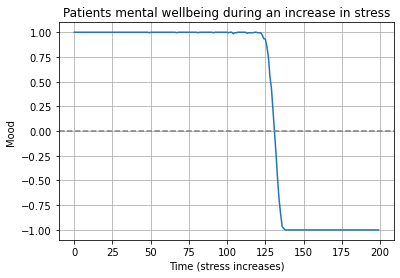

In [29]:
# 400 node network
G = nx.grid_2d_graph(20, 20, periodic=True)

# Start in a healthy environment, with high coupling between nodes, and temperature slightly below the critical
model = IsingSimulation(G, H=2.0, J=2.5, T=2.0, length=200, warmup=50)

model.run(delta_H=-0.05)

print(np.round(model.order(), 2))

plt.plot(model.order())
plt.title("Patients mental wellbeing during an increase in stress")
plt.xlabel("Time (stress increases)")
plt.ylabel("Mood ")
plt.axhline(0, color='gray', linestyle='--')
plt.grid(True)
plt.show()

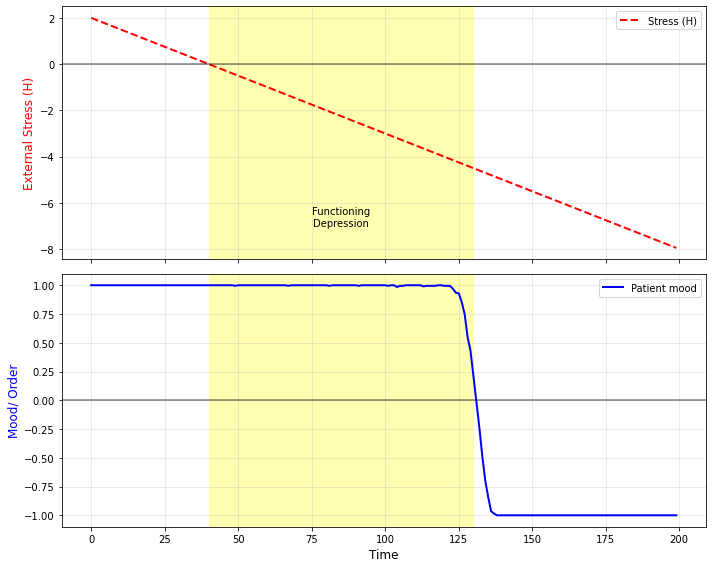

In [38]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# top plot
ax1.plot(model.h_history, color='red', linestyle='--', linewidth=2, label="Stress (H)")
ax1.axhline(0, color='black', alpha=0.5)
ax1.set_ylabel("External Stress (H)", color='red', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right')


# Where the outside stress is negative so unhealthy
bad_environment = model.h_history < 0

# Where the patients mood is still healthy, bellow 0
good_mood = model.order_history > 0

# The points where the stress is negative but the mood is still positive
metastable_indices = np.where(bad_environment & good_mood)[0]

# If there are any points where the above conditions are valid draw a yelow zone
if len(metastable_indices) > 0:
    start = metastable_indices[0]
    end = metastable_indices[-1]
    ax1.axvspan(start, end, color='yellow', alpha=0.3)
    ax1.text((start+end)/2, -7.0, "Functioning\nDepression", ha='center', fontsize=10)

# bottom plot
ax2.plot(model.order_history, color='blue', linewidth=2, label="Patient mood")
ax2.axhline(0, color='black', alpha=0.5)
ax2.set_ylabel("Mood/ Order", color='blue', fontsize=12)
ax2.set_xlabel("Time", fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper right')

# Yellow zone of the bottom graph
if len(metastable_indices) > 0:
    ax2.axvspan(start, end, color='yellow', alpha=0.3)


plt.tight_layout()
plt.show()

## Model Validation

### Parameter sweep h

In [ ]:
# iteratate over h and plot the order at the end of the simulation at each h
# TODO: @Julia

### Parameter sweep J

In [ ]:
# iteratate over h and plot the order at the end of the simulation at each J
# TODO: @Julia

### Investigate stochastic effects

In [ ]:
# run several iterations of the simulation at, near, and far from the CP using both high and low noise.
# plot results including mean and variance.
# TODO: @Kyle

### Hysteresis check

In [ ]:
# use the delta_h parameter in the run function to slowly increase h past the critical point, then reduce back to starting value.
# plot the order parameter and h as a function of time.
# answers H5
# TODO: @Kyle

### Power Law analysis

In [ ]:
# perform power law analysis, drawing inspiration from percolation theory
# TODO: @Julia

## Research Questions

In [ ]:
# RQ1: To what extent can the largest eigenvalue of the symptom covariance matrix (σ1) predict critical transitions from a "healthy" to a "depressed" state within a simulated symptom network?
# slowly increase h past critical point. plot order, largest eigenvalue, and h as a function of time.
# answers H1/H3
# TODO: @Kyle

In [ ]:
# H2: for the above simulation, plot dominant eigenvalue as percentage of total variance explained
# TODO: @Igor

In [ ]:
# analyze the eigenvector corresponding to the largest eigenvalue
# H4
# TODO: @Julia

## Animation

In [ ]:
# create an animation showing the evolution of the network over time
# TODO: @Kyle